In [1]:
import sys; sys.path.append("..")
from openbabel import openbabel as ob
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from networkx.algorithms import isomorphism
from sqlalchemy.orm import Session
import os
import networkx as nx
from src import utils
# connect to database
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
engine = create_engine("sqlite:///{}".format("../main.db"))
session = sessionmaker(bind=engine)()
all_sids = [x[0] for x in session.execute(text("SELECT id FROM structures")).all()]

In [2]:
IMPORTANT_CYCLCES = {
    "pyrrole1": set([1, 13, 14, 15, 22]),
    "pyrrole2": set([2, 3, 4, 5, 16]),
    "pyrrole3": set([7, 8, 9, 10, 11]),
    "pyrrole4": set([17, 18, 19, 20, 23]),
    "inner_cross": set([2, 16, 5, 12, 13, 14, 22, 24, 23, 17, 18, 21, 11, 9, 7, 6]),
    "outer_circuit": set([1, 22, 24, 23, 20, 19, 18, 21, 11, 10, 8, 7, 6, 2, 4, 3, 5, 12, 13, 15])
}

In [3]:
def get_definition(structure: str):
    mol = utils.get_molecule(os.path.join("../data", "definitions", structure + ".mol"))
    return utils.mol_to_graph(mol)


def find_structure_indices(obmol: ob.OBMol, structure: str):
    subgraph = get_definition(structure)
    g = utils.mol_to_graph(obmol)
    iso = isomorphism.GraphMatcher(g, subgraph, node_match=utils.node_matcher)
    morph = list(iso.subgraph_isomorphisms_iter())
    return morph

def get_macrocycle_atoms(mol: ob.OBMol):
    while True:
        for atom in ob.OBMolAtomIter(mol):
            if atom.GetAtomicNum() == 1:
                mol.DeleteAtom(atom)
                break
        else:
            break
        
    mol.ConnectTheDots()
    mapper = find_structure_indices(mol, "porphyrins")[0]
    porphyrin_atoms = [k for k, v in sorted(mapper.items(), key=lambda item: item[1])]
    metal_idx = None
    for atom_idx in porphyrin_atoms:
        atom = mol.GetAtom(atom_idx)
        if atom.GetAtomicNum() != 7:
            continue
        for nbr in ob.OBAtomAtomIter(atom):
            nbr_idx = nbr.GetIdx()
            if nbr_idx not in porphyrin_atoms and nbr.GetAtomicNum() != 7:
                metal_idx = nbr_idx
    porphyrin_atoms.append(metal_idx)
    return porphyrin_atoms

def get_macrocycle_bonds(mol: ob.OBMol):
    atom_idxs = get_macrocycle_atoms(mol)
    mol.ConnectTheDots()
    bonds = []
    covered = set()
    for idx in atom_idxs:
        atom = mol.GetAtom(idx)
        covered.add(idx)
        for bond in ob.OBAtomBondIter(atom):
            bidx = bond.GetBeginAtomIdx()
            eidx = bond.GetEndAtomIdx()
            if eidx in covered and bidx in covered: 
                continue
            if bidx in atom_idxs and eidx in atom_idxs:
                bonds.append(bond)
    return bonds


def get_atoms(reference: str):
    mol = utils.get_molecule(reference)
    idxs = get_macrocycle_atoms(mol)
    coords_3d = np.array([[mol.GetAtom(idx).GetX(), mol.GetAtom(idx).GetY(), mol.GetAtom(idx).GetZ()] for idx in idxs])
    centroid = coords_3d.mean(axis=0)
    coords_centered = coords_3d - centroid
    u, s, vh = np.linalg.svd(coords_centered)
    plane_x = vh[0]
    plane_y = vh[1]
    points_2d = [(np.dot(coord - centroid, plane_x), np.dot(coord - centroid, plane_y)) for coord in coords_3d]
    return points_2d

def get_macrocycle_atom_mapper(mol: ob.OBMol):
    """Get the atoms involved in the macrocycle, including the metal center."""
    # Remove all hydrogen atoms
    while True:
        for atom in ob.OBMolAtomIter(mol):
            if atom.GetAtomicNum() == 1:
                mol.DeleteAtom(atom)
                break
        else:
            break

    mol.ConnectTheDots()
    atom_mapper = find_structure_indices(mol, "porphyrins")[0]
    metal_idx = None
    for atom_idx in atom_mapper.keys():
        atom = mol.GetAtom(atom_idx)
        if atom.GetAtomicNum() != 7:  # Skip non-nitrogen atoms
            continue
        for nbr in ob.OBAtomAtomIter(atom):
            nbr_idx = nbr.GetIdx()
            if nbr_idx not in atom_mapper.keys() and nbr.GetAtomicNum() != 7:
                metal_idx = nbr_idx
    if metal_idx:
        atom_mapper[metal_idx] = -1
    return atom_mapper

def get_structures_with(session: Session, source: str):
    q = f"SELECT DISTINCT structure FROM structure_properties WHERE source LIKE '%{source}%'"
    ajr = session.execute(text(q))
    return list(map(lambda x: x[0], ajr))

def get_currents(sid: str, session: Session, height: float=None, width: float=None, mapped: bool=True, total: bool=False):
    indices = "mapped" if mapped else "original"
    q = f"SELECT * FROM structure_properties WHERE structure='{sid}' AND source LIKE 'gimic%' AND property LIKE '%current/{indices}%'"
    if height is not None:
        q += f" AND source LIKE '%h={height:.1f}%'"
    if width is not None:
        q += f" AND source LIKE '%w={width:.1f}%'"
    df = pd.read_sql(q, session.connection())
    df["begin"] = [int(s.split("/")[-1].split("->")[0]) for s in df["property"]]
    df["end"] = [int(s.split("/")[-1].split("->")[1]) for s in df["property"]]
    df["height"] = [float(s.split("h=")[1].split("&")[0]) for s in df["source"]]
    df["width"] = [float(s.split("w=")[1]) for s in df["source"]]
    if not total:
        return df[["begin", "end", "value", "height", "width"]]
    # return total currents if requested
    df["bid"] = [f"{min(x)}_{max(x)}" for x in df[["begin", "end"]].values]
    df["factor"] = [1 if f"{begin}_{end}" == bid else -1 for begin, end, bid in df[["begin", "end", "bid"]].values]
    df["value"] = df["value"] * df["factor"]
    ajr = df[["bid", "value"]].groupby("bid").sum()
    ajr["begin"] = [int(x.split("_")[0]) for x in ajr.index]
    ajr["end"] = [int(x.split("_")[1]) for x in ajr.index]
    return ajr


def get_acid_values(sid: str, session: Session, radius: float=None):
    q = f"SELECT * FROM structure_properties WHERE structure='{sid}' AND source LIKE 'acid%' AND property LIKE '%mapped%'"
    if radius is not None:
        q += f" AND source LIKE '%radius={radius}%'"
    df = pd.read_sql(q, session.connection())
    df["begin"] = [int(s.split("/")[-1].split("->")[0]) for s in df["property"]]
    df["end"] = [int(s.split("/")[-1].split("->")[1]) for s in df["property"]]
    df["radius"] = [float(s.split("radius=")[1]) for s in df["source"]]
    return df[["begin", "end", "value", "radius"]]


def plot_currents(ax, points, currents):
    # Normalize bond integral values for coloring
    integral_values = np.abs(np.array([d["value"] for d in currents]))
    vmin, vmax = integral_values.min(), integral_values.max()
    norm = plt.Normalize(vmin, vmax)
    cmap = plt.get_cmap('Greens')

    # Draw bonds
    for d in currents:
        a1, a2, val = max(d["begin"] - 1, -1), max(d["end"] - 1, -1), d["value"]
        x1, y1 = points[a1]
        x2, y2 = points[a2]
        ax.plot([x1, x2], [y1, y2], color=cmap(norm(abs(val))), linewidth=3)
        # Draw arrow at the center of the bond, pointing along the bond direction
        xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
        dx, dy = 1e-6 * (x2 - x1) / 2, 1e-6 * (y2 - y1) / 2
        if val > 0:
            ax.arrow(xm, ym, dx, dy, color="gray", width=0.05, length_includes_head=False, head_width=0.2, head_length=0.3, alpha=0.8)
        else:
            ax.arrow(xm, ym, -dx, -dy, color="gray", width=0.05, length_includes_head=False, head_width=0.2, head_length=0.3, alpha=0.8)

    # Draw atoms
    for x, y in points:
        ax.scatter(x, y, color='black', s=60)

    ax.set_aspect('equal')
    ax.axis('off')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Induced Current (nA/T)")

def plot_acid(ax, points, bond_acid_values):
    # Normalize acid values for coloring
    vs = [d["value"] for d in bond_acid_values]
    vmin, vmax = min(vs), max(vs)
    norm = plt.Normalize(vmin, vmax)
    cmap = plt.get_cmap('Greens')

    # Draw bonds colored by acid value
    for d in bond_acid_values:
        x1, y1 = points[max(d["begin"] - 1, -1)]
        x2, y2 = points[max(d["end"] - 1, -1)]
        color = cmap(norm(d["value"]))
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=3)

    # Draw atoms
    for x, y in points:
        ax.scatter(x, y, color='black', s=60)

    ax.set_aspect('equal')
    ax.axis('off')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Acid Value")

def analyze_cycles(df: pd.DataFrame):
    G = nx.DiGraph()
    for _, row in df.iterrows():
        v = row["value"]
        if v > 0:
            G.add_edge(int(row['begin']), int(row['end']), value=v)
        else:
            G.add_edge(int(row['end']), int(row['begin']), value=-v)
    cycles = list(nx.simple_cycles(G))
    cycle_labels = []
    for cyc in cycles:
        cyc_set = set(cyc)
        if -1 in cyc_set:
            label = "metal"
        else:
            label = None
            for name, nodes in IMPORTANT_CYCLCES.items():
                if cyc_set == nodes:
                    label = name
                    break
            if label is None:
                label = "other"
        cycle_labels.append(label)

    cycle_stats = []
    for cyc, label in zip(cycles, cycle_labels):
        edge_vals = []
        for i in range(len(cyc)):
            a = cyc[i]
            b = cyc[(i + 1) % len(cyc)]
            # Try both directions
            if G.has_edge(a, b):
                edge_vals.append(G[a][b]["value"])
            elif G.has_edge(b, a):
                edge_vals.append(G[b][a]["value"])
        if edge_vals:
            # Count unique pyrroles in the cycle
            pyrrole_indices = set()
            for node in cyc:
                for pyrrole_name in ["pyrrole1", "pyrrole2", "pyrrole3", "pyrrole4"]:
                    if node in IMPORTANT_CYCLCES[pyrrole_name]:
                        pyrrole_indices.add(pyrrole_name)
            cycle_stats.append({
                "cycle": label,
                "min": np.min(edge_vals),
                "max": np.max(edge_vals),
                "sum": np.sum(edge_vals),
                "avg": np.mean(edge_vals),
                "n_bonds": len(edge_vals),
                "current_cover": np.sum(edge_vals) / np.sum([abs(data["value"]) for _, _, data in G.edges(data=True)]),
                "n_pyrroles": len(pyrrole_indices)
            })

    result_df = pd.DataFrame(cycle_stats)
    return result_df


MACROCYCLE_POINTS = get_atoms("../data/nmr/ATEWUT_0_out/gimic/mol.xyz")

In [4]:
get_structures_with(session, "gimic")

['LODSEC',
 'QAYRIS01',
 'QIJXEM',
 'LODRAX',
 'LIYDOM',
 'LIRFOJ',
 'LEZLAD',
 'LAXDIX',
 'LAXCOC',
 'LARKEV',
 'KOXSAT',
 'KIZSOC',
 'JUVXAB',
 'JOCHOZ',
 'IZAFIZ',
 'IWISAK',
 'ISAZEJ',
 'INIBAL',
 'HUWTAW',
 'HOHZIO',
 'HIZCEA',
 'HAMGUX',
 'QENJOI',
 'EREDUA',
 'ECUBAH',
 'ZOXQUA',
 'ZOHQUK',
 'ZUZPIV',
 'ZOHQOE',
 'ZEJMIM',
 'ZEJMUY',
 'ZITNIZ',
 'ZEKXOE',
 'ZITLUJ02',
 'ZEKXOE01',
 'YOWJID',
 'YESKOZ',
 'YEQPOA',
 'YEQPIU',
 'YEQMOW',
 'YEFPEF',
 'YAJNAZ',
 'YAJLUT',
 'YEHDAR',
 'YASDOO',
 'XUZYUO',
 'XOFKIM',
 'XIXRII',
 'XEZVED',
 'XEZVED01',
 'XEYVUS',
 'XEFWIO',
 'VOFDIE',
 'VIMZUN',
 'VICDUH',
 'VICDOB',
 'VICCUG',
 'VEXTAV',
 'VEXSIC',
 'VEFZOY',
 'VAVRER',
 'VAVRAN',
 'VAFTUR',
 'VAFQIC',
 'UVUCIY',
 'UTEYIE',
 'TOCZES',
 'TOCZAO',
 'SULCUX',
 'SEVCUR',
 'RUTQAY',
 'RUTMUO',
 'RIRNUB',
 'REFPOH',
 'NUGMUA',
 'QAKJUH',
 'QARCOD',
 'NEMXOT',
 'MOWPEW',
 'NACXIA',
 'LODSAY',
 'LIYDUS',
 'LIYDEC',
 'LIBCEE',
 'LEFWOJ',
 'LAXDAP',
 'LAXBER',
 'KUDLEB',
 'KOGQUT',
 'JOLKEC',
 '

In [5]:
from scipy.interpolate import LinearNDInterpolator
from scipy.optimize import minimize


sid = "GIXCIB"
df = get_currents(sid, session, height=None, width=None, total=False)
df

G = nx.DiGraph()
# Get unique (begin, end) pairs
unique_pairs = df[["begin", "end"]].drop_duplicates().values

for begin, end in unique_pairs:
    # Select all rows for this bond (both directions)
    bond_df = df[(df["begin"] == begin) & (df["end"] == end)]
    # Prepare points and values for interpolation
    points = bond_df[["height", "width"]].values
    values = bond_df["value"].values
    interpolator = LinearNDInterpolator(points, values)
    G.add_edge(int(begin), int(end), value_interpolator=interpolator, hmax=bond_df["height"].max(), wmax=bond_df["width"].max())

edge_to_idx = {}
for u, v in G.edges:
    id = (min(u, v), max(u, v))
    if id not in edge_to_idx:
        edge_to_idx[id] = len(edge_to_idx)

def edge_idx(u, v):
    return edge_to_idx[(min(u, v), max(u, v))]

def target(hvec, wvec):
    ajr = 0
    for node in G.nodes:
        influx = sum([G.edges[v, node]["value_interpolator"](hvec[edge_idx(v, node)], wvec[edge_idx(v, node)]) for v in G.predecessors(node)])
        outflux = sum([G.edges[node, v]["value_interpolator"](hvec[edge_idx(v, node)], wvec[edge_idx(v, node)]) for v in G.successors(node)])
        ajr += (outflux - influx) ** 2
    return ajr

bounds = [(1.5, G.edges[edge]["hmax"]) for edge in G.edges if edge in edge_to_idx] + [(1.5, G.edges[edge]["wmax"]) for edge in G.edges if edge in edge_to_idx]
x0 = [2.5] * len(edge_to_idx) + [2.5] * len(edge_to_idx)

def vector_target(x):
    hvec = x[:len(edge_to_idx)]
    wvec = x[len(edge_to_idx):]
    return target(hvec, wvec)


result = minimize(vector_target, x0=x0, bounds=bounds, method="Powell")
print(result.message)
x_opt = result.x
h_opt = x_opt[:len(edge_to_idx)]
w_opt = x_opt[len(edge_to_idx):]

for u, v in G.edges:
    print(f"{u} -> {v} = h: {h_opt[edge_idx(u, v)]:.3f}, w: {w_opt[edge_idx(u, v)]:.3f}")
print("*****")
print(f"target: {result.fun:.6f}")

data = []
for node in G.nodes:
    influx = sum([G.edges[v, node]["value_interpolator"](h_opt[edge_idx(v, node)], w_opt[edge_idx(v, node)]) for v in G.predecessors(node)])
    outflux = sum([G.edges[node, v]["value_interpolator"](h_opt[edge_idx(v, node)], w_opt[edge_idx(v, node)]) for v in G.successors(node)])
    data.append([node, outflux, influx])

kirk = pd.DataFrame(data, columns=["atom", "influx", "outflux"])
kirk["diff"] = kirk["outflux"] - kirk["influx"]
print(kirk["diff"].abs().mean())
kirk



Optimization terminated successfully.
15 -> 1 = h: 2.500, w: 1.882
15 -> 13 = h: 3.000, w: 1.882
1 -> 15 = h: 2.500, w: 1.882
1 -> 22 = h: 3.000, w: 1.882
13 -> 15 = h: 3.000, w: 1.882
13 -> 12 = h: 3.571, w: 1.882
13 -> 14 = h: 2.981, w: 1.882
12 -> 13 = h: 3.571, w: 1.882
12 -> 5 = h: 3.127, w: 1.882
14 -> 13 = h: 2.981, w: 1.882
14 -> 22 = h: 2.779, w: 1.882
14 -> -1 = h: 1.500, w: 1.882
5 -> 12 = h: 3.127, w: 1.882
5 -> 3 = h: 3.000, w: 1.882
5 -> 16 = h: 1.890, w: 1.882
3 -> 5 = h: 3.000, w: 1.882
3 -> 4 = h: 4.500, w: 1.882
16 -> 5 = h: 1.890, w: 1.882
16 -> 2 = h: 2.560, w: 1.882
16 -> -1 = h: 2.646, w: 1.882
4 -> 3 = h: 4.500, w: 1.882
4 -> 2 = h: 2.646, w: 1.882
2 -> 4 = h: 2.646, w: 1.882
2 -> 6 = h: 2.646, w: 1.882
2 -> 16 = h: 2.560, w: 1.882
6 -> 2 = h: 2.646, w: 1.882
6 -> 7 = h: 2.646, w: 1.882
7 -> 6 = h: 2.646, w: 1.882
7 -> 8 = h: 2.646, w: 1.882
7 -> 9 = h: 2.646, w: 1.882
8 -> 7 = h: 2.646, w: 1.882
8 -> 10 = h: 2.646, w: 1.882
9 -> 7 = h: 2.646, w: 1.882
9 -> 11 = 

,atom,influx,outflux,diff
0,15,34.166890,32.657053,-1.509837
1,1,19.421441,46.493944,27.072502
2,13,55.350947,34.829764,-20.521184
3,12,34.903827,28.704396,-6.199431
4,14,48.111338,35.647874,-12.463464
5,5,61.915484,46.365830,-15.549654
6,3,10.421432,22.713749,12.292317
7,16,53.057150,51.676626,-1.380525
8,4,28.177994,6.256503,-21.921491
9,2,64.289656,58.457002,-5.832654


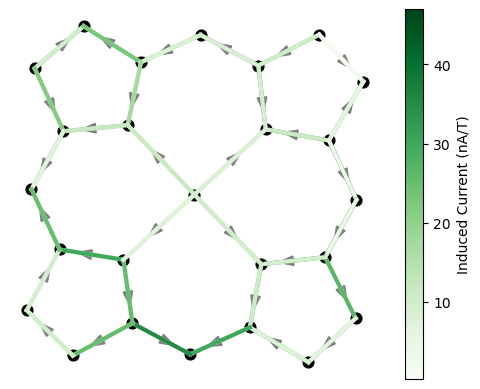

In [6]:
ajr = []
for u, v in G.edges:
    ajr.append({"begin": u, "end": v, "value": G.edges[u, v]["value_interpolator"](h_opt[edge_idx(u, v)], w_opt[edge_idx(u, v)])})

df = pd.DataFrame(ajr)
df["bid"] = [f"{min(x)}_{max(x)}" for x in df[["begin", "end"]].values]
df["factor"] = [1 if f"{begin}_{end}" == bid else -1 for begin, end, bid in df[["begin", "end", "bid"]].values]
df["value"] = df["value"] * df["factor"]
ajr = df[["bid", "value"]].groupby("bid").sum()
ajr["begin"] = [int(x.split("_")[0]) for x in ajr.index]
ajr["end"] = [int(x.split("_")[1]) for x in ajr.index]
plot_currents(plt.gca(), MACROCYCLE_POINTS, df.to_dict(orient="records"))

           value  begin  end
bid                         
-1_14 -10.844968     -1   14
-1_16  -0.512654     -1   16
-1_17   2.396214     -1   17
-1_9   -8.453329     -1    9
10_11 -20.476255     10   11
11_21  36.787814     11   21
12_13  35.261659     12   13
13_14  28.095349     13   14
13_15 -16.368451     13   15
14_22 -22.900543     14   22
17_18 -22.882191     17   18
17_23  19.514231     17   23
18_19 -14.857143     18   19
18_21 -37.387855     18   21
19_20  58.148551     19   20
1_15  -72.733145      1   15
1_22   26.403962      1   22
20_23  26.355609     20   23
22_24  39.704093     22   24
23_24  38.597938     23   24
2_16   20.748618      2   16
2_4    19.806633      2    4
2_6   -39.398880      2    6
3_4   -25.596570      3    4
3_5    27.865367      3    5
5_12   37.477734      5   12
5_16  -21.385004      5   16
6_7    40.308612      6    7
7_8    17.412630      7    8
7_9   -20.244910      7    9
8_10   21.691424      8   10
9_11   18.559955      9   11


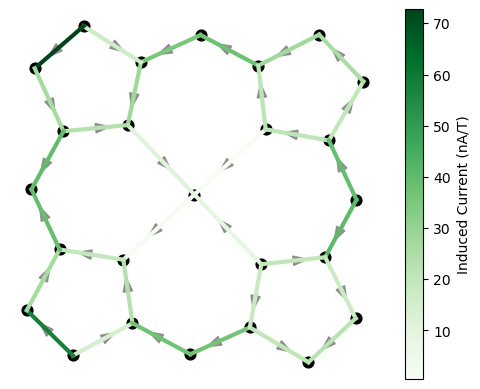

In [24]:
sid = "JUVXAB"
# fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
df = get_currents(sid, session, height=2.5, width=3.5, total=True)
print(df)
# df = currents[(currents["height"] == 2) & (currents["width"] == 3)]
plot_currents(plt.gca(), MACROCYCLE_POINTS, df[["begin", "end", "value"]].to_dict(orient='records'))
# df = get_acid_values(sid, session, radius=4)
# df = df[(df["begin"] != -1) & (df["end"] != -1)]
# plot_acid(axs[1], MACROCYCLE_POINTS, df.to_dict(orient="records"))
# plt.tight_layout()

In [27]:
sids = get_structures_with(session, "gimic")
cycles = []
for sid in sids:
    df = get_currents(sid, session, height=3, width=2)
    c = analyze_cycles(df)
    c["sid"] = sid
    if len(c) == len(c.dropna()):
        cycles.append(c)

In [30]:
data = []
idx = []
for c in cycles:
    print(c)
    if len(c) == 0:
        continue
    pyrrole_current = 0
    pyrrole_coverage = 0
    inner_cross_current = 0
    inner_cross_coverage = 0
    outer_circuit_current = 0
    outer_circuit_coverage = 0
    for _, row in c.iterrows():
        if "pyrrole" in str(row["cycle"]):
            pyrrole_current += row["sum"]
            pyrrole_coverage += row["current_cover"]
        if row["cycle"] == "inner_cross":
            inner_cross_current += row["sum"]
            inner_cross_coverage += row["current_cover"]
        if row["cycle"] == "outer_circuit":
            outer_circuit_current += row["sum"]
            outer_circuit_coverage += row["current_cover"]
    if len(c) > 0:
        metal_cycles = c[c["cycle"] == "metal"]
    else:
        metal_cycles = []
    if len(metal_cycles) > 0:
        idx_max = metal_cycles["current_cover"].idxmax()
        metal_current = metal_cycles.loc[idx_max, "sum"]
        metal_coverage = metal_cycles.loc[idx_max, "current_cover"]
    else:
        metal_current = 0
        metal_coverage = 0
    data.append({
        "sid": c["sid"].values[0],
        "pyrrole_current": pyrrole_current,
        "pyrrole_coverage": pyrrole_coverage,
        "metal_current": metal_current,
        "metal_coverage": metal_coverage,
        "inner_cross_current": inner_cross_current,
        "inner_cross_coverage": inner_cross_coverage,
        "outer_circuit_current": outer_circuit_current,
        "outer_circuit_coverage": outer_circuit_coverage,
    })
current_summary = pd.DataFrame(data)

     cycle       min        max         sum        avg  n_bonds  \
0    other  9.610324  30.976741   40.587065  20.293533        2   
1    metal  1.593456  48.015898  263.527822  21.960652       12   
2    metal  2.789349  48.015898  354.924413  20.877907       17   
3    metal  2.789349  48.015898  324.406980  23.171927       14   
4    metal  2.789349  48.015898  411.606965  19.600332       21   
..     ...       ...        ...         ...        ...      ...   
291  other  8.290940  28.141181   36.432121  18.216061        2   
292  other  8.316575  33.753893   42.070468  21.035234        2   
293  other  7.624307  35.536055   43.160362  21.580181        2   
294  other  7.234921  36.096283   43.331204  21.665602        2   
295  other  8.247792  28.801672   37.049464  18.524732        2   

     current_cover  n_pyrroles     sid  
0         0.035492           1  LODSEC  
1         0.230447           2  LODSEC  
2         0.310370           3  LODSEC  
3         0.283683           3 

In [31]:
# fetch all data
from src.sqlmodels import StructureProperty
# fetch all rows matching the filter and convert to DataFrame
rows = session.query(StructureProperty).filter(StructureProperty.source.like("%nics%")).all()
nics = pd.DataFrame([r.__dict__ for r in rows]).drop('_sa_instance_state', axis=1)
# fabulize dataframe
nics["pyrrole"] = [int(x.split("/")[0][-1]) for x in nics["property"]]
nics["z"] = [float(x.split("/")[1][1:]) for x in nics["property"]]
nics["type"] = [x.split("/")[-1] for x in nics["property"]]
nics["value"] = - nics["value"] # to obey the convention of NICS notation
nics = nics[["structure", "pyrrole", "z", "type", "value"]]
nics_zz = nics[nics["type"] == "zz"].groupby(by=["structure", "pyrrole"]).min().reset_index()
nics_zz1 = nics[nics["type"] == "zz"][nics["z"] == 1]
nics_isotropic = nics[nics["type"] == "isotropic"].groupby(by=["structure", "pyrrole"]).min().reset_index()

/tmp/ipykernel_3215/3286161071.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nics_zz1 = nics[nics["type"] == "zz"][nics["z"] == 1]


In [44]:
pyrrole_values = []
cycles_sids = []
for cycles_df in cycles:
    if len(cycles_df) == 0:
        continue
    sid = cycles_df["sid"].values[0]
    cycles_sids.append(sid)
    for label in ["pyrrole1", "pyrrole2", "pyrrole3", "pyrrole4"]:
        if len(cycles_df) == 0:
            pyrrole_values.append(0)
            continue
        v = cycles_df[cycles_df["cycle"] == label]
        if len(v) > 0:
            pyrrole_values.append(v["sum"].values[0])
        else:
            pyrrole_values.append(0)
ajr = nics_zz1[nics_zz1["structure"].isin(cycles_sids)].copy()
print(ajr)
ajr["gimic"] = pyrrole_values
print(ajr)

      structure  pyrrole    z type      value
9420     ECUBAH        1  1.0   zz  -4.986355
9471     ECUBAH        2  1.0   zz  -3.493172
9522     ECUBAH        3  1.0   zz  -2.011654
9573     ECUBAH        4  1.0   zz  -1.916119
10644    EREDUA        1  1.0   zz -13.778327
...         ...      ...  ...  ...        ...
62196    ZOXQUA        4  1.0   zz -16.697543
62247    ZUZPIV        1  1.0   zz -24.827515
62298    ZUZPIV        2  1.0   zz -25.212644
62349    ZUZPIV        3  1.0   zz -19.159710
62400    ZUZPIV        4  1.0   zz -21.848382

[348 rows x 5 columns]


ValueError: Length of values (368) does not match length of index (348)

In [33]:
plt.scatter(ajr["value"], ajr["gimic"])

KeyError: 'gimic'

Cycle 1: nodes=[1, 22, 14, 13, 15]
  Sum: 0.9237, Min: 0.1119, Max: 0.4210
Cycle 2: nodes=[1, 22, 14, -1, 16, 2, 4, 3, 5, 12, 13, 15]
  Sum: 1.7520, Min: 0.0067, Max: 0.4367
Cycle 3: nodes=[1, 22, 14, -1, 17, 23, 20, 19, 18, 21, 11, 10, 8, 7, 6, 2, 4, 3, 5, 12, 13, 15]
  Sum: 3.2285, Min: 0.0008, Max: 0.4524
Cycle 4: nodes=[1, 22, 24, 23, 20, 19, 18, 21, 11, 10, 8, 7, 6, 2, 4, 3, 5, 12, 13, 15]
  Sum: 2.9998, Min: 0.0008, Max: 0.4524
Cycle 5: nodes=[1, 22, 24, 23, 20, 19, 18, 21, 11, 10, 8, 7, 9, -1, 16, 2, 4, 3, 5, 12, 13, 15]
  Sum: 3.2459, Min: 0.0067, Max: 0.4524
Cycle 6: nodes=[7, 9, 11, 10, 8]
  Sum: 0.9231, Min: 0.1176, Max: 0.4025
Cycle 7: nodes=[7, 9, -1, 17, 23, 20, 19, 18, 21, 11, 10, 8]
  Sum: 1.7227, Min: 0.0067, Max: 0.4524
Cycle 8: nodes=[17, 23, 20, 19, 18]
  Sum: 0.9897, Min: 0.1155, Max: 0.4524
Cycle 9: nodes=[2, 4, 3, 5, 16]
  Sum: 1.0121, Min: 0.1209, Max: 0.4367


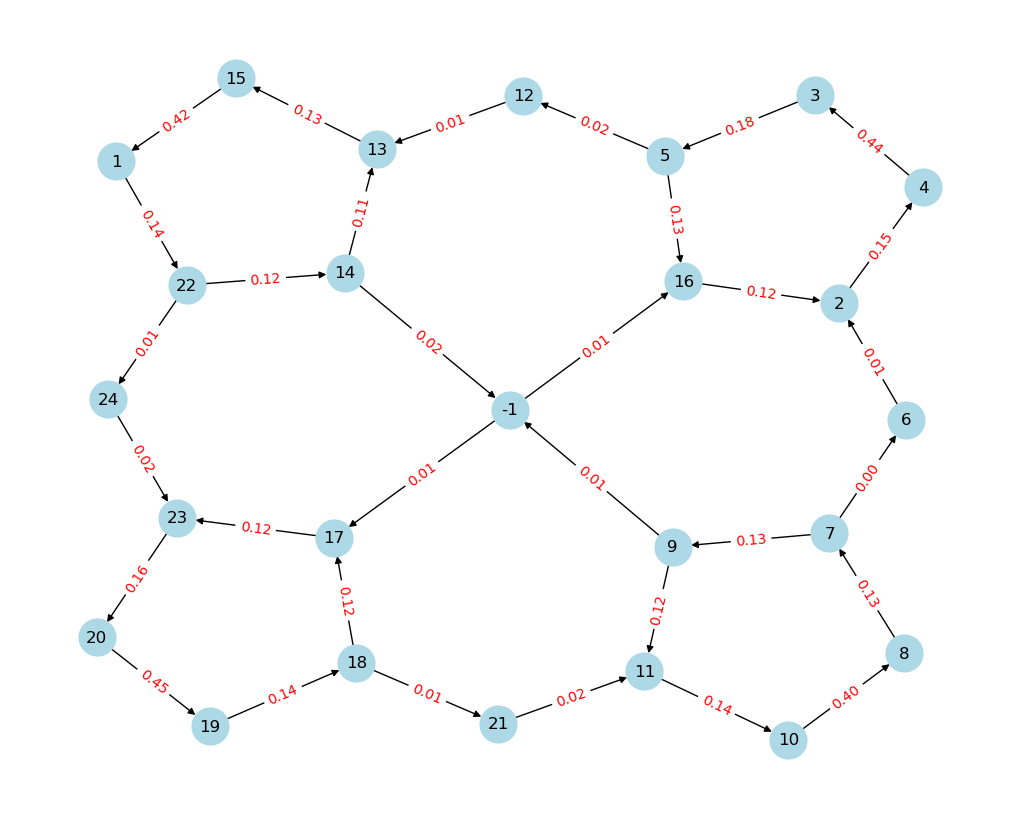

In [32]:
import networkx as nx

sid = "ARODOC"

df = get_currents(sid, session, height=3, width=2)

# Build a directed graph from the DataFrame
G = nx.DiGraph()
for _, row in df.iterrows():
    v = row["value"]
    if v > 0:
        G.add_edge(int(row['begin']), int(row['end']), value=v)
    else:
        G.add_edge(int(row['end']), int(row['begin']), value=-v)


# Use MACROCYCLE_POINTS for node positions (node indices start from 1, -1 is special)
pos = {}
for idx, (x, y) in enumerate(MACROCYCLE_POINTS, start=1):
    pos[idx] = (x, y)
if -1 in G.nodes:
    # Place the special node -1 at the centroid
    pos[-1] = (np.mean([x for x, y in MACROCYCLE_POINTS]), np.mean([y for x, y in MACROCYCLE_POINTS]))

edge_labels = {(u, v): f"{d['value']:.2f}" for u, v, d in G.edges(data=True)}
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=700, arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Find all simple cycles in the graph
cycles = list(nx.simple_cycles(G))

# For each cycle, compute sum, min, and max of the currents
for i, cycle in enumerate(cycles, 1):
    # Get the list of edges in the cycle
    edges = [(cycle[j], cycle[(j + 1) % len(cycle)]) for j in range(len(cycle))]
    # Get the current values for these edges
    currents = [G[u][v]['value'] for u, v in edges]
    print(f"Cycle {i}: nodes={cycle}")
    print(f"  Sum: {sum(currents):.4f}, Min: {min(currents):.4f}, Max: {max(currents):.4f}")


In [ ]:
sids = get_structures_with(session, "gimic")
widths = [2 + 0.5 * i for i in range(16)]
heights = [2 + 0.5 * i for i in range(16)]
print(widths.index(3), heights.index(5))
grad_norm = np.zeros(shape=(len(widths), len(heights)))
histvalues = []
for sid in sids:
    df = get_currents(sid, session, mapped=False)
    df["bond"] = [f"{b}->{e}" for b, e in df[["begin", "end"]].values]
    sgrads = np.zeros_like(grad_norm)
    for bond in df["bond"].unique():
        # Create a pivot table for the heatmap
        heatmap_data = df[df["bond"] == bond].pivot_table(index="height", columns="width", values="value", aggfunc="first")
        grad_y, grad_x = np.gradient(heatmap_data.values, edge_order=2)
        ajr = np.sqrt(grad_x**2 + grad_y**2)
        ajr = np.nan_to_num(ajr, nan=0)
        if any(pd.isna(ajr.flatten())):
            print(ajr)
        histvalues.append(ajr[min(heights.index(4), ajr.shape[0] - 1), min(widths.index(3), ajr.shape[1] - 1)])
        padded = np.zeros_like(sgrads)
        padded[:ajr.shape[0], :ajr.shape[1]] = ajr
        sgrads += padded
    sgrads = sgrads / len(df["bond"].unique())
    grad_norm += sgrads
grad_norm = grad_norm / len(sids)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(grad_norm, aspect='auto', cmap="Oranges", origin='lower')
for i in range(grad_norm.shape[0]):
    for j in range(grad_norm.shape[1]):
        ax.text(j, i, f"{grad_norm[i, j]:.2e}", ha='center', va='center', fontsize=8, color='black')
ax.set_xticks(np.arange(grad_norm.shape[1]), widths)
ax.set_yticks(np.arange(grad_norm.shape[0]), heights)
ax.set_xlabel("Width index")
ax.set_ylabel("Height index")
ax.set_title("Average Gradient Norm Heatmap")
fig.colorbar(im, ax=ax, label='Average |Gradient|')
plt.tight_layout()
plt.figure()
plt.hist(np.clip(histvalues, -5e-1, 5e-1), bins=50)
plt.show()


['29->31', '59->33', '62->37', '42->39', '45->42', '51->48', '51->65', '58->54', '61->65', '64->68', '72->68', '68->69', '72->75', '75->79', '83->25', '25->29', '79->83', '65->1', '69->1', '1->62', '1->59']


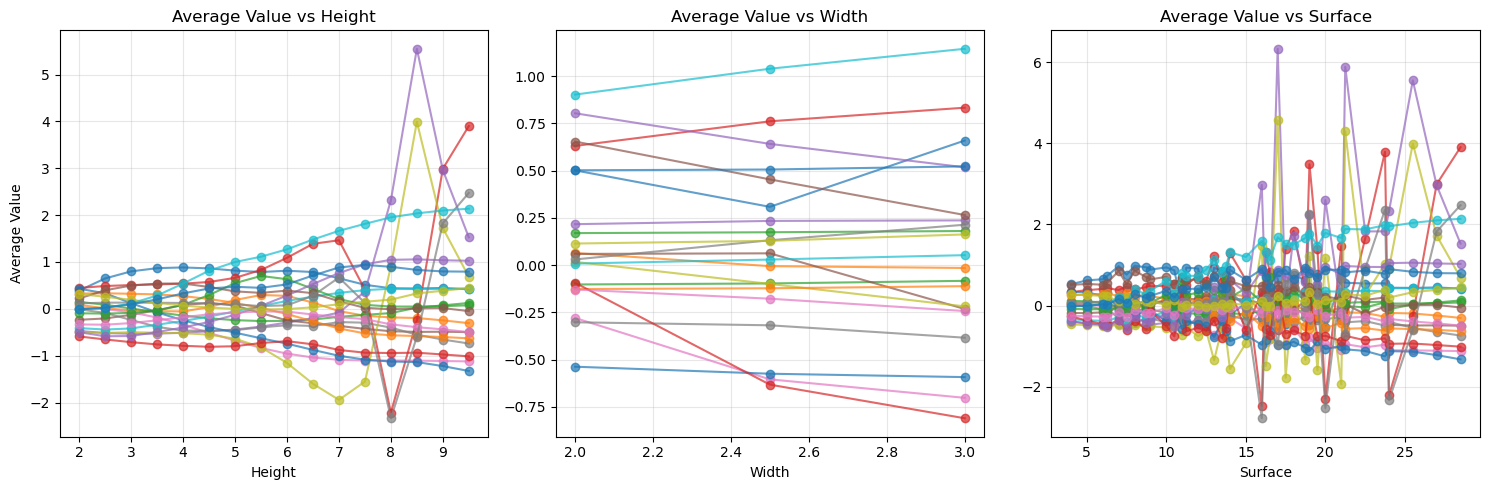

In [60]:
df = get_currents("BUVKOV", session, mapped=False)
df["bond"] = [f"{b}->{e}" for b, e in df[["begin", "end"]].values]
df["surface"] = df["height"] * df["width"]

changing_signs = [b for b in df["bond"].unique() if any(df[df["bond"] == b]["value"] > 1e-2) and any(df[df["bond"] == b]["value"] < -1e-2)]
df = df[df["bond"].isin(changing_signs)]
print(changing_signs)
# Normalize values for each bond
# for bond in df["bond"].unique():
#     bond_data = df[df["bond"] == bond]
#     start_value = bond_data[(bond_data["height"] == bond_data["height"].min()) & (bond_data["width"] == bond_data["width"].min())]["value"].iloc[0]
#     df.loc[df["bond"] == bond, "value"] = (df.loc[df["bond"] == bond, "value"] - start_value) * np.sign(start_value)

# print(df[df["value"] < -1e-3].groupby("bond").min().sort_values("value"))

# Create pivot tables for averaging values``
pivot_height = df[df["width"] == 3].pivot_table(index="height", columns="bond", values="value", aggfunc="mean")
pivot_width = df.pivot_table(index="width", columns="bond", values="value", aggfunc="mean")
pivot_surface = df.pivot_table(index="surface", columns="bond", values="value", aggfunc="mean")


# Create subplots
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))

# Plot average values vs height
for bond in pivot_height.columns:
    values = pivot_height[bond].dropna().values
    axs[0].plot(pivot_height.index, pivot_height[bond], marker="o", label=str(bond), alpha=0.7)
axs[0].set_xlabel("Height")
axs[0].set_ylabel("Average Value")
axs[0].set_title("Average Value vs Height")
axs[0].grid(True, alpha=0.3)

# Plot average values vs width
for bond in pivot_width.columns:
    values = pivot_width[bond].dropna().values
    axs[1].plot(pivot_width.index, pivot_width[bond], marker="o", label=str(bond), alpha=0.7)
axs[1].set_xlabel("Width")
axs[1].set_title("Average Value vs Width")
axs[1].grid(True, alpha=0.3)

# Plot average values vs surface
for bond in pivot_surface.columns:
    values = pivot_surface[bond].dropna().values
    axs[2].plot(pivot_surface.index, pivot_surface[bond], marker="o", label=str(bond), alpha=0.7)
axs[2].set_xlabel("Surface")
axs[2].set_title("Average Value vs Surface")
axs[2].grid(True, alpha=0.3)
# axs[2].legend()


plt.tight_layout()
plt.show()

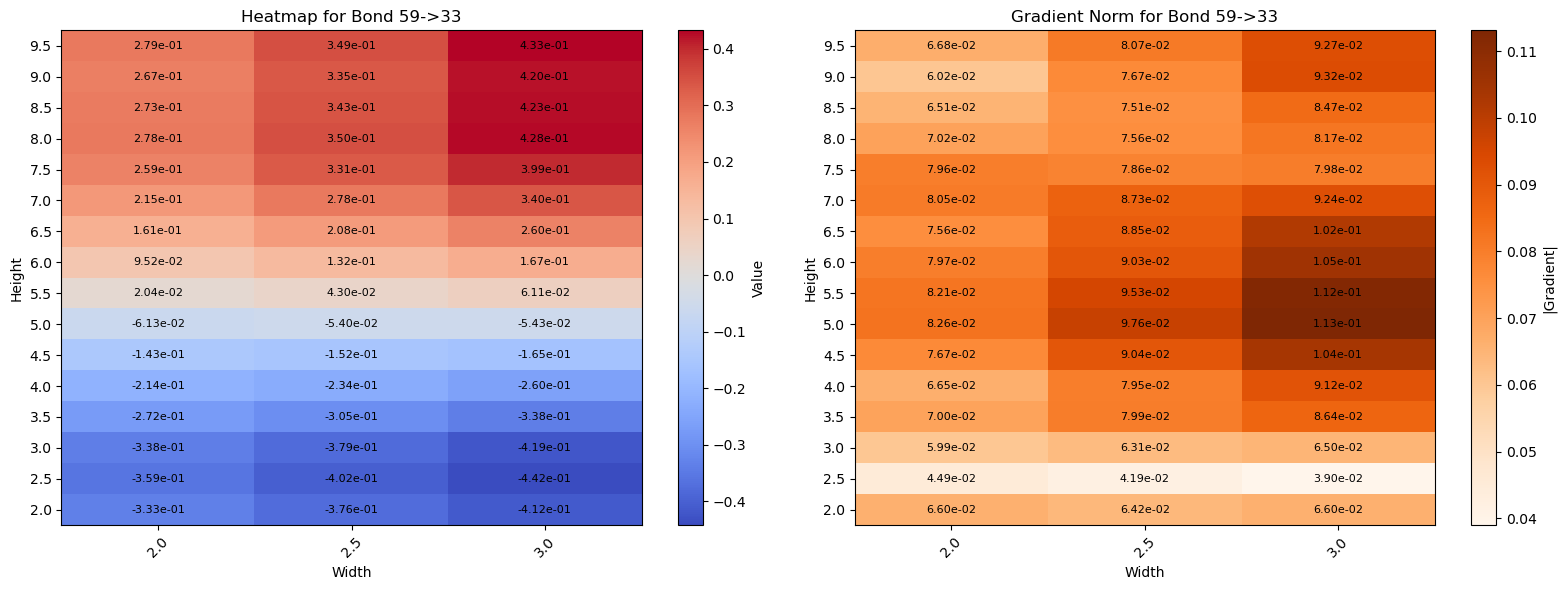

In [62]:

df = get_currents("BUVKOV", session, mapped=False)
df["bond"] = [f"{b}->{e}" for b, e in df[["begin", "end"]].values]

# Normalize values for each bond
# for bond in df["bond"].unique():
#     bond_data = df[df["bond"] == bond]
#     start_value = bond_data[(bond_data["height"] == bond_data["height"].min()) & (bond_data["width"] == bond_data["width"].min())]["value"].iloc[0]
#     df.loc[df["bond"] == bond, "value"] = (df.loc[df["bond"] == bond, "value"] - start_value) * np.sign(start_value)

# print(df[df["value"] < -1e-3].groupby("bond").min().sort_values("value"))

bond = "59->33"
# Create a pivot table for the heatmap
heatmap_data = df[df["bond"] == bond].pivot_table(index="height", columns="width", values="value", aggfunc="first")


# Plot the heatmap
fig, axs = plt.subplots(ncols=2, figsize=(16, 6))

im0 = axs[0].imshow(heatmap_data, aspect='auto', cmap="coolwarm", origin='lower')
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        axs[0].text(j, i, f"{heatmap_data.iloc[i, j]:.2e}", ha='center', va='center', fontsize=8, color='black')

axs[0].set_xticks(np.arange(heatmap_data.shape[1]))
axs[0].set_xticklabels(heatmap_data.columns, rotation=45)
axs[0].set_yticks(np.arange(heatmap_data.shape[0]))
axs[0].set_yticklabels(heatmap_data.index)
axs[0].set_title(f"Heatmap for Bond {bond}")
axs[0].set_xlabel("Width")
axs[0].set_ylabel("Height")
fig.colorbar(im0, ax=axs[0], label='Value')

# Compute gradient norm
grad_y, grad_x = np.gradient(heatmap_data.values, edge_order=2)
grad_norm = np.sqrt(grad_x**2 + grad_y**2)

im1 = axs[1].imshow(grad_norm, aspect='auto', cmap="Oranges", origin='lower')
for i in range(grad_norm.shape[0]):
    for j in range(grad_norm.shape[1]):
        axs[1].text(j, i, f"{grad_norm[i, j]:.2e}", ha='center', va='center', fontsize=8, color='black')

axs[1].set_xticks(np.arange(heatmap_data.shape[1]))
axs[1].set_xticklabels(heatmap_data.columns, rotation=45)
axs[1].set_yticks(np.arange(heatmap_data.shape[0]))
axs[1].set_yticklabels(heatmap_data.index)
axs[1].set_title(f"Gradient Norm for Bond {bond}")
axs[1].set_xlabel("Width")
axs[1].set_ylabel("Height")
fig.colorbar(im1, ax=axs[1], label='|Gradient|')

plt.tight_layout()
plt.show()


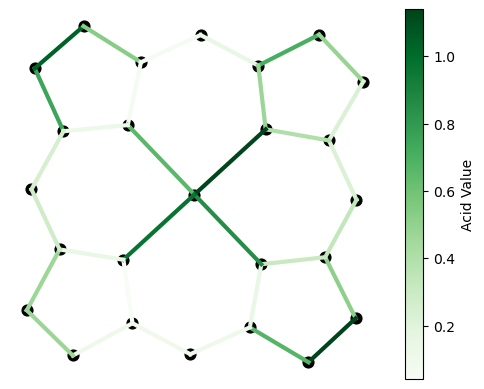

In [37]:
df = get_acid_values("ATUSOX", session, radius=4)
plot_acid(plt.gca(), MACROCYCLE_POINTS, df.to_dict(orient="records"))

In [2]:
xyz_path = "../data/nmr/ATUSOX_0_out/gimic/mol.xyz"
mol = utils.get_molecule(xyz_path)
mol.DeleteHydrogens()

True

In [3]:
jvec_vti_file = "../data/nmr/ATUSOX_0_out/gimic/jvec.vti"
vtk_data = gutils.read_vti_file(jvec_vti_file)

In [4]:
# Extract all metadata from vtk_data
print(vtk_data.GetInformation())


vtkInformation (0x55f2a9049f70)
  Debug: Off
  Modified Time: 361
  Reference Count: 2
  Registered Events: (none)
  DATA_NUMBER_OF_GHOST_LEVELS: 0
  DATA_NUMBER_OF_PIECES: 1
  DATA_PIECE_NUMBER: 0
  DATA_EXTENT: 0 300 0 283 0 186
  DATA_EXTENT_TYPE: 1




In [7]:
while True:
    for atom in ob.OBMolAtomIter(mol):
        if atom.GetAtomicNum() == 1:
            mol.DeleteAtom(atom)
            break
    else:
        break
    
mol.ConnectTheDots()
porphyrin_atoms = list(find_structure_indices(mol, "porphyrins")[0].keys())
metal_idx = None
for atom_idx in porphyrin_atoms:
    atom = mol.GetAtom(atom_idx)
    if atom.GetAtomicNum() != 7:
        continue
    for nbr in ob.OBAtomAtomIter(atom):
        nbr_idx = nbr.GetIdx()
        if nbr_idx not in porphyrin_atoms and nbr.GetAtomicNum() != 7:
            metal_idx = nbr_idx
porphyrin_atoms.append(metal_idx)



In [8]:
def calculate_flux_through_bond(bond: ob.OBBond, vti_data: vtk.vtkImageData, surface_width: float, surface_height: float):
    """
    Calculates the flux of a vector field through a bond.

    Args:
        bond (ob.OBBond): An OpenBabel bond object.
        vti_file (str): Path to the .vti file containing the vector field.
        bond_radius (flat): Radius of bond to calcualte flux

    Returns:
        float: The flux of the vector field through the bond.
    """
    # extract the vector function
    vector_function = gutils.get_vector_function(vti_data)

    # Get the bond's start and end points
    atom1 = bond.GetBeginAtom()
    atom2 = bond.GetEndAtom()
    start = np.array([atom1.GetX(), atom1.GetY(), atom1.GetZ()])
    end = np.array([atom2.GetX(), atom2.GetY(), atom2.GetZ()])

    # Calculate the bond's center and direction
    center = (start + end) / 2
    direction = end - start
    normal = direction / np.linalg.norm(direction)

    # Calculate the flux through the bond
    return gutils.calculate_flux_through_plane_adaptive(vector_function, center, surface_width, surface_height, normal, N=10)

In [9]:
def calculate_bond_integrals(width, height, data):
    # print("Calculating with radius", bond_radius)
    bond_integrals = {}
    for atom_idx in porphyrin_atoms:
        atom_obj = mol.GetAtom(atom_idx)
        for nbr in ob.OBAtomAtomIter(atom_obj):
            nbr_idx = nbr.GetIdx()
            if nbr_idx in porphyrin_atoms and atom_idx < nbr_idx:
                bond = mol.GetBond(atom_obj.GetIdx(), nbr.GetIdx())
                integral = calculate_flux_through_bond(
                    bond, data, width, height
                )
                bond_integrals[(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())] = integral
    return bond_integrals

# Calculate bond integrals for bond_radius = 1, 2, 3, 4
widths = [1, 1.5, 2, 2.5, 3]
heights = [1, 1.5, 2, 2.5, 3]
ajr = []
for w in widths:
    for h in heights:
        print("running with w={}, h={}".format(w, h))
        ints = calculate_bond_integrals(w, h, vtk_data)
        ajr.extend([{"width": w, "height": h, "bond": k, "flux": v} for k, v in ints.items()])


# Create DataFrame with (atom1, atom2) as index and columns for each radius
df_bond_integrals = pd.DataFrame(ajr)
df_bond_integrals


running with w=1, h=1
running with w=1, h=1.5
running with w=1, h=2
running with w=1, h=2.5
running with w=1, h=3
running with w=1.5, h=1
running with w=1.5, h=1.5
running with w=1.5, h=2
running with w=1.5, h=2.5
running with w=1.5, h=3
running with w=2, h=1
running with w=2, h=1.5
running with w=2, h=2
running with w=2, h=2.5
running with w=2, h=3
running with w=2.5, h=1
running with w=2.5, h=1.5
running with w=2.5, h=2
running with w=2.5, h=2.5
running with w=2.5, h=3
running with w=3, h=1
running with w=3, h=1.5
running with w=3, h=2
running with w=3, h=2.5
running with w=3, h=3


,width,height,bond,flux
0,1.0,1.0,"(6, 5)",-0.142616
1,1.0,1.0,"(7, 6)",-0.067440
2,1.0,1.0,"(8, 7)",0.018448
3,1.0,1.0,"(20, 7)",-0.062177
4,1.0,1.0,"(23, 8)",0.019526
...,...,...,...,...
795,3.0,3.0,"(4, 3)",0.016853
796,3.0,3.0,"(53, 1)",-0.043275
797,3.0,3.0,"(21, 1)",0.054021
798,3.0,3.0,"(1, 19)",-0.106969


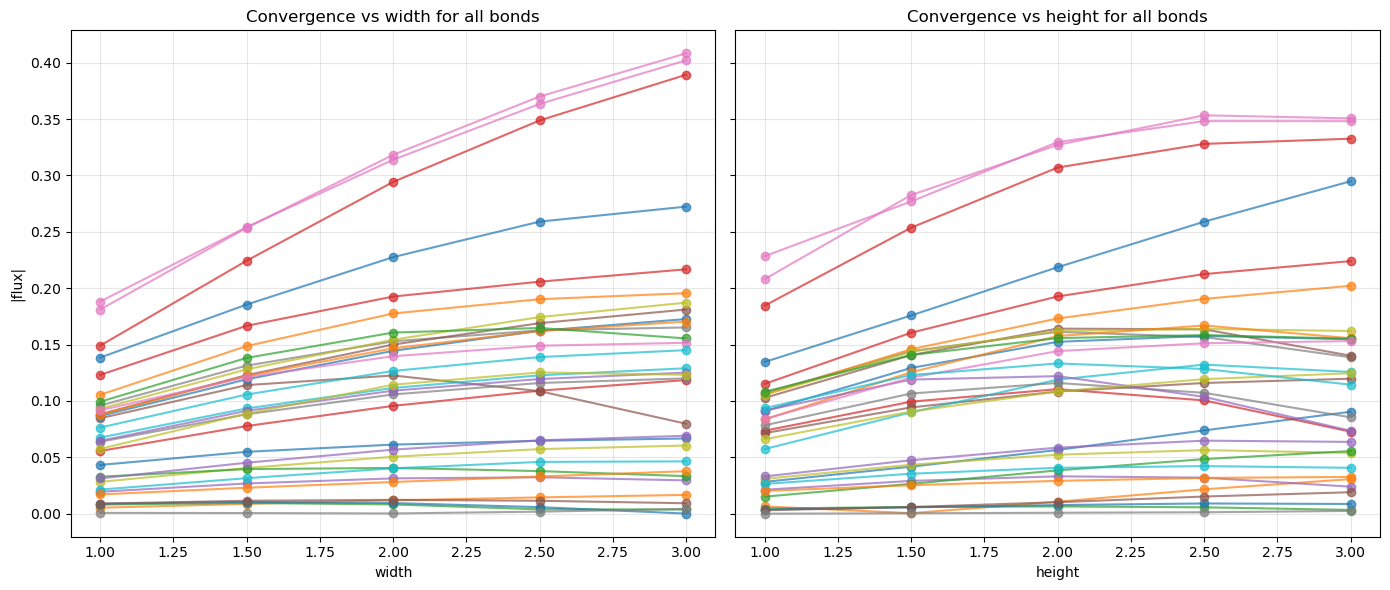

In [11]:
# Plot |flux| vs width and vs height for all bonds in the same plot

# Pivot the dataframe for easier plotting
pivot_w = df_bond_integrals.pivot_table(index="width", columns="bond", values="flux", aggfunc="mean")
pivot_h = df_bond_integrals.pivot_table(index="height", columns="bond", values="flux", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# |flux| vs width for each bond (one line per bond)
for bond in pivot_w.columns:
    axes[0].plot(pivot_w.index, pivot_w[bond].abs(), marker='o', label=str(bond), alpha=0.7)
axes[0].set_xlabel('width')
axes[0].set_ylabel('|flux|')
axes[0].set_title('Convergence vs width for all bonds')
axes[0].grid(True, alpha=0.3)

# |flux| vs height for each bond (one line per bond)
for bond in pivot_h.columns:
    axes[1].plot(pivot_h.index, pivot_h[bond].abs(), marker='o', label=str(bond), alpha=0.7)
axes[1].set_xlabel('height')
axes[1].set_title('Convergence vs height for all bonds')
axes[1].grid(True, alpha=0.3)

# Optionally, show legend for a subset of bonds to avoid clutter
handles, labels = axes[1].get_legend_handles_labels()
# if len(labels) > 15:
#     axes[1].legend(handles[:15], labels[:15], title='bond (showing 15)', fontsize=8)
# else:
#     axes[1].legend(title='bond', fontsize=8)

plt.tight_layout()
plt.show()
